In [34]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [8]:
df = pd.read_csv(r"C:\Users\athar\AI Projects\telecom-fault-rag-lora\data\processed\telecom_fault_dataset.csv")
df.tail()

,incident_id,timestamp,network_element,region,raw_log,alarm_type,kpi_summary,packet_loss_percent,latency_ms,call_drop_rate,throughput_mbps,rrc_failure_rate,handover_failure_rate,prb_utilization,sinr_db,fault_category,root_cause,severity,resolution_steps,source_dataset
3995,INC_003996,2024-03-03 08:33:00,AggregationRouter_4345,Hyderabad-HITEC-City,- 1122165890 2005.07.23 R15-M1-NA-C:J13-U11 20...,Application Core Dump,"packet_loss=2.45%, latency=116.91ms, call_drop...",2.45,116.91,6.96,19.88,3.77,1.31,62.98,19.42,Application Crash,Application process crash generated core dump,High,Restart impacted service and monitor for recur...,Loghub-BGL
3996,INC_003997,2024-03-03 16:45:00,MME_5167,Mumbai-West,- 1125083438 2005.08.26 R60-M0-NE-C:J10-U11 20...,No Major Alarm,"packet_loss=1.07%, latency=39.82ms, call_drop_...",1.07,39.82,0.47,62.93,1.09,0.84,35.54,20.07,Normal,Network operating within acceptable KPI thresh...,Low,Continue monitoring network KPIs,Loghub-BGL
3997,INC_003998,2024-03-02 19:03:00,CellSite_8758,Chennai-OMR,- 1121256367 2005.07.13 R20-M1-NA-C:J04-U11 20...,Process Crash,"packet_loss=11.6%, latency=150.26ms, call_drop...",11.60,150.26,6.63,25.15,3.55,4.17,69.15,21.63,Application Crash,Runtime process failure,High,Check application logs and control stream conn...,Loghub-BGL
3998,INC_003999,2024-03-03 02:16:00,MME_2428,Bengaluru-East,Received block blk_-4358842839092719327 of siz...,Data Transfer Delay,"packet_loss=6.27%, latency=192.66ms, call_drop...",6.27,192.66,3.43,43.98,2.65,1.64,77.57,16.13,Transport Degradation,High transport latency during data transfer,High,"Check throughput, interface utilization, and t...",Loghub-HDFS
3999,INC_004000,2024-03-04 06:20:00,AggregationRouter_6217,Gurugram-Sector-44,Deleting block blk_8761138012128091849 file /m...,Block Transfer Latency,"packet_loss=8.12%, latency=168.84ms, call_drop...",8.12,168.84,2.94,24.91,4.31,4.50,63.88,22.52,Transport Degradation,High transport latency during data transfer,High,Monitor transfer delay and escalate if degrada...,Loghub-HDFS


In [10]:
df.shape

(4000, 20)

In [12]:
df.dtypes

incident_id                  str
timestamp                    str
network_element              str
region                       str
raw_log                      str
alarm_type                   str
kpi_summary                  str
packet_loss_percent      float64
latency_ms               float64
call_drop_rate           float64
throughput_mbps          float64
rrc_failure_rate         float64
handover_failure_rate    float64
prb_utilization          float64
sinr_db                  float64
fault_category               str
root_cause                   str
severity                     str
resolution_steps             str
source_dataset               str
dtype: object

In [13]:
df.isnull().sum()

incident_id              0
timestamp                0
network_element          0
region                   0
raw_log                  0
alarm_type               0
kpi_summary              0
packet_loss_percent      0
latency_ms               0
call_drop_rate           0
throughput_mbps          0
rrc_failure_rate         0
handover_failure_rate    0
prb_utilization          0
sinr_db                  0
fault_category           0
root_cause               0
severity                 0
resolution_steps         0
source_dataset           0
dtype: int64

In [26]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   incident_id            4000 non-null   str    
 1   timestamp              4000 non-null   str    
 2   network_element        4000 non-null   str    
 3   region                 4000 non-null   str    
 4   raw_log                4000 non-null   str    
 5   alarm_type             4000 non-null   str    
 6   kpi_summary            4000 non-null   str    
 7   packet_loss_percent    4000 non-null   float64
 8   latency_ms             4000 non-null   float64
 9   call_drop_rate         4000 non-null   float64
 10  throughput_mbps        4000 non-null   float64
 11  rrc_failure_rate       4000 non-null   float64
 12  handover_failure_rate  4000 non-null   float64
 13  prb_utilization        4000 non-null   float64
 14  sinr_db                4000 non-null   float64
 15  fault_category 

In [24]:
df.columns

Index(['incident_id', 'timestamp', 'network_element', 'region', 'raw_log',
       'alarm_type', 'kpi_summary', 'packet_loss_percent', 'latency_ms',
       'call_drop_rate', 'throughput_mbps', 'rrc_failure_rate',
       'handover_failure_rate', 'prb_utilization', 'sinr_db', 'fault_category',
       'root_cause', 'severity', 'resolution_steps', 'source_dataset'],
      dtype='str')

In [20]:
df['fault_category'].value_counts()

fault_category
Transport Degradation    1243
Application Crash        1075
Normal                    525
Memory/Cache Error        429
Backhaul Issue            342
Configuration Error       250
Core Network Issue         81
Interference               51
Hardware Failure            3
Power Outage                1
Name: count, dtype: int64

In [27]:

df['fault_category'].unique()

<StringArray>
[   'Memory/Cache Error',   'Configuration Error', 'Transport Degradation',
     'Application Crash',                'Normal',        'Backhaul Issue',
          'Interference',    'Core Network Issue',          'Power Outage',
      'Hardware Failure']
Length: 10, dtype: str

In [28]:
df[['raw_log', 'alarm_type', 'kpi_summary', 'fault_category']].sample(10)

,raw_log,alarm_type,kpi_summary,fault_category
88,10.251.66.102:50010:Got exception while servin...,Control Plane Processing Error,"packet_loss=3.54%, latency=120.79ms, call_drop...",Core Network Issue
1739,- 1125379628 2005.08.29 R26-M0-NC-I:J18-U01 20...,Process Crash,"packet_loss=5.68%, latency=197.61ms, call_drop...",Application Crash
411,- 1133455517 2005.12.01 R43-M1-ND-C:J08-U01 20...,No Major Alarm,"packet_loss=1.43%, latency=51.95ms, call_drop_...",Normal
3333,10.251.214.32:50010 Served block blk_-65200304...,Transport Throughput Degradation,"packet_loss=9.22%, latency=143.8ms, call_drop_...",Transport Degradation
330,- 1121006676 2005.07.10 R30-M1-N9-C:J10-U01 20...,Application Core Dump,"packet_loss=4.82%, latency=232.18ms, call_drop...",Application Crash
2197,APPSEV 1134630981 2005.12.14 R37-M1-N8-I:J18-U...,Backhaul Latency Spike,"packet_loss=10.79%, latency=226.67ms, call_dro...",Backhaul Issue
2461,Receiving block blk_8235751201501175836 src: /...,Data Transfer Delay,"packet_loss=4.99%, latency=118.46ms, call_drop...",Transport Degradation
2117,Received block blk_-1522107359378428427 of siz...,Transport Throughput Degradation,"packet_loss=9.3%, latency=189.07ms, call_drop_...",Transport Degradation
3417,- 1122167255 2005.07.23 R16-M1-NB-C:J06-U01 20...,Memory Parity Alarm,"packet_loss=3.26%, latency=78.27ms, call_drop_...",Memory/Cache Error
585,PacketResponder 2 for block blk_-1049340855430...,Backhaul Packet Loss Alarm,"packet_loss=20.82%, latency=227.6ms, call_drop...",Backhaul Issue


In [29]:
df['raw_log'].str.len().describe()

count    4000.000000
mean      126.001250
std        72.525594
min        49.000000
25%        93.000000
50%       127.000000
75%       139.000000
max      2480.000000
Name: raw_log, dtype: float64

In [30]:
df['kpi_summary'].str.len().describe()

count    4000.000000
mean      169.113250
std         1.047234
min       165.000000
25%       169.000000
50%       169.000000
75%       170.000000
max       172.000000
Name: kpi_summary, dtype: float64

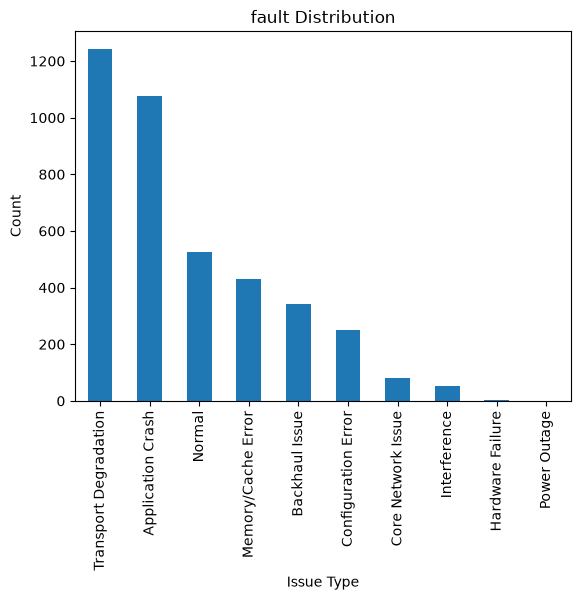

In [ ]:
df['fault_category'].value_counts().plot(kind='bar')


plt.title("fault Distribution")
plt.xlabel("Issue Type")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [51]:
df['log_length'] = df['raw_log'].astype(str).str.len()

In [52]:
df[['raw_log','log_length']].head(10)

,raw_log,log_length
0,- 1120266925 2005.07.01 R25-M1-N2-C:J10-U01 20...,149
1,BLOCK* NameSystem.delete: blk_3280859030919654...,96
2,- 1120259941 2005.07.01 R25-M1-N2-C:J08-U01 20...,149
3,Receiving block blk_3598226258881465924 src: /...,94
4,BLOCK* NameSystem.delete: blk_-438534717113603...,96
5,- 1118122888 2005.06.06 R25-M1-N8-C:J06-U01 20...,127
6,KERNTERM 1132111168 2005.11.15 R57-M0-NA-C:J13...,153
7,KERNSTOR 1118767955 2005.06.14 R11-M1-N6-C:J12...,137
8,- 1118765825 2005.06.14 R13-M0-NA-C:J15-U01 20...,139
9,- 1120973021 2005.07.09 R04-M1-NB-C:J15-U01 20...,127


In [53]:
df['log_length'].describe()

count    4000.000000
mean      126.001250
std        72.525594
min        49.000000
25%        93.000000
50%       127.000000
75%       139.000000
max      2480.000000
Name: log_length, dtype: float64

Text(0, 0.5, 'Frequency')

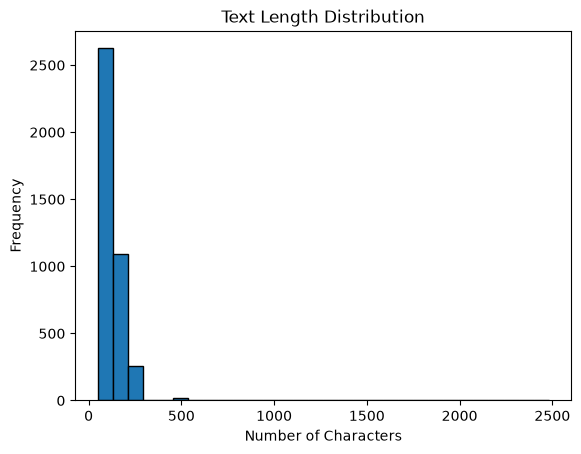

In [57]:
plt.hist(df['log_length'], bins=30, edgecolor='black')
plt.title('Text Length Distribution')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')

<Axes: xlabel='fault_category'>

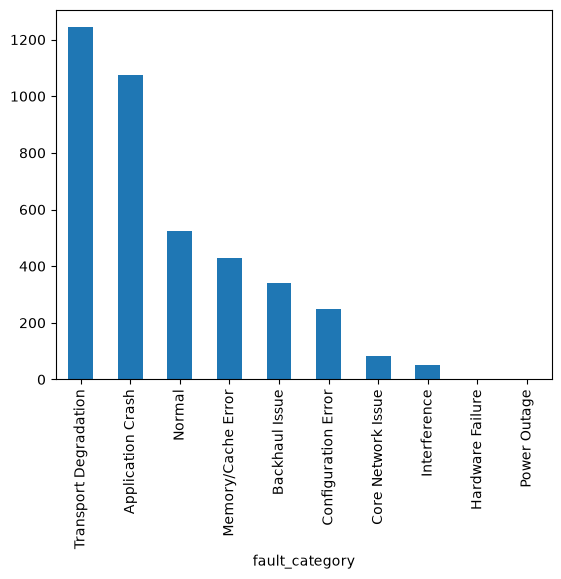

In [58]:
df['fault_category'].value_counts().plot(kind='bar')

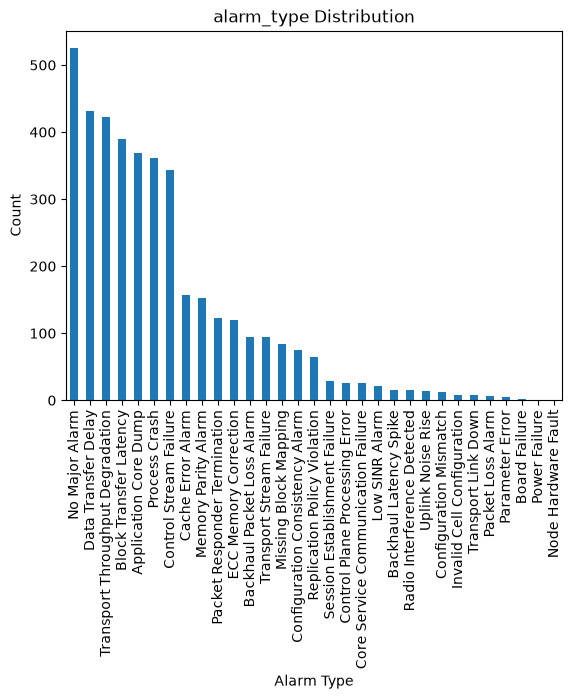

In [64]:
df['alarm_type'].value_counts().plot(kind='bar')

plt.title("alarm_type Distribution")
plt.xlabel("Alarm Type")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

## EDA Observations

- The dataset contains **4,000 records** and **20 features**.
- No missing values were found, indicating good data quality.
- The target variable is **`fault_category`**, making this a **multi-class classification** problem.
- The dataset is **imbalanced**, with some fault categories having significantly fewer samples than others.
- The baseline model will use **`raw_log`**, **`alarm_type`**, and **`kpi_summary`** as input features. These text columns will be combined and converted into numerical features using **TF-IDF Vectorization**.